In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

In [2]:
data = ekd.from_source("sample", "efas.nc").to_fieldlist()
data.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,dis06,2022-10-08 18:00:00,2022-10-08 12:00:00,0 days 06:00:00,0.0,surface,None,None
1,land_binary_mask,2022-10-08 18:00:00,2022-10-08 12:00:00,0 days 06:00:00,0.0,surface,None,None
2,upArea,2022-10-08 18:00:00,2022-10-08 12:00:00,0 days 06:00:00,0.0,surface,None,None


In [3]:
ds = ekd.from_source("sample", "efas.nc").to_xarray()
ds

/Users/mavj/opt/miniconda3/envs/DEVELOP/lib/python3.11/site-packages/earthkit/data/readers/netcdf/reader.py:82: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_dataset(


<xarray.Dataset> Size: 24MB
Dimensions:                       (y: 950, x: 1000)
Coordinates:
  * y                             (y) float64 8kB 5.498e+06 ... 7.525e+05
  * x                             (x) float64 8kB 2.502e+06 ... 7.498e+06
    time                          datetime64[ns] 8B ...
    step                          timedelta64[ns] 8B ...
    surface                       float64 8B ...
    latitude                      (y, x) float64 8MB ...
    longitude                     (y, x) float64 8MB ...
    valid_time                    datetime64[ns] 8B ...
Data variables:
    dis06                         (y, x) float32 4MB ...
    lambert_azimuthal_equal_area  int32 4B ...
    land_binary_mask              (y, x) int8 950kB ...
    upArea                        (y, x) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2022-11-10T10:57 GRIB to CDM+CF via cfgrib-0.9.9...

In [7]:
ds2 = ds.assign_coords(
    lambert_azimuthal_equal_area=ds.lambert_azimuthal_equal_area
)

In [8]:
ds2

<xarray.Dataset> Size: 24MB
Dimensions:                       (y: 950, x: 1000)
Coordinates:
  * y                             (y) float64 8kB 5.498e+06 ... 7.525e+05
  * x                             (x) float64 8kB 2.502e+06 ... 7.498e+06
    lambert_azimuthal_equal_area  int32 4B ...
    time                          datetime64[ns] 8B 2022-10-08T12:00:00
    step                          timedelta64[ns] 8B 06:00:00
    surface                       float64 8B 0.0
    latitude                      (y, x) float64 8MB 66.98 67.01 ... 23.96 23.94
    longitude                     (y, x) float64 8MB -35.03 -34.94 ... 41.14
    valid_time                    datetime64[ns] 8B 2022-10-08T18:00:00
Data variables:
    dis06                         (y, x) float32 4MB nan nan nan ... nan nan nan
    land_binary_mask              (y, x) int8 950kB 0 0 0 0 0 0 ... 1 1 1 1 1 1
    upArea                        (y, x) float32 4MB nan nan nan ... nan nan nan
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2022-11-10T10:57 GRIB to CDM+CF via cfgrib-0.9.9...

/Users/mavj/opt/miniconda3/envs/DEVELOP/lib/python3.11/site-packages/earthkit/data/readers/netcdf/fieldlist.py:61: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_mfdataset(


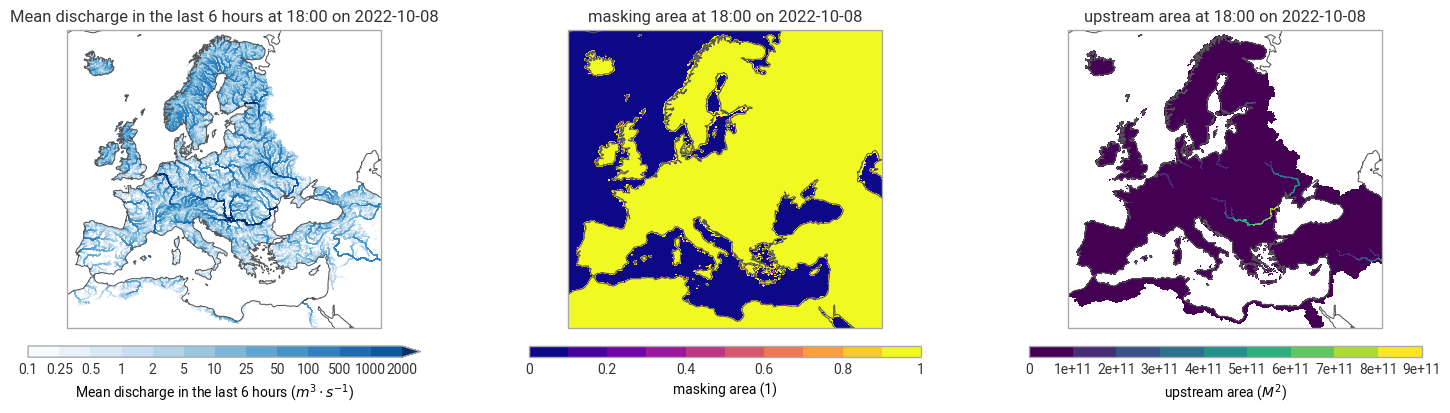

In [12]:
ekp.geo.plot(data)